In [1]:
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

### NOTE:
Adding my observations at the end of each cell as an inline comment, marked with #OBS:

In [2]:
#DATA LOADING
df = pd.read_pickle('../data/training_data.pkl')

In [3]:
ARTEFACTS_DIRECTORY = '../artifacts/'

### Dataset Inspection

In [4]:
# SHAPE ADN DTYPE

print(f'Shape: {df.shape}\n')
print(f'Dtypes:\n\n{df.dtypes}')

Shape: (1200, 2)

Dtypes:

timeseries_data    object
label              object
dtype: object


In [5]:
# NaN COUNT
print(f'Null counts:\n{df.isnull().sum()}')

#OBS: No Null values, data imputation not required

Null counts:
timeseries_data    0
label              0
dtype: int64


In [6]:
print(df.head())

#OBS: timeseries_data is an array of dicts

                                     timeseries_data          label
0  [{'timestamp': 1700000712, 'temperature': 110....             WO
1  [{'timestamp': 1700000696, 'temperature': 48.2...  NO_WORK_ORDER
2  [{'timestamp': 1700000593, 'temperature': 50.1...  NO_WORK_ORDER
3  [{'timestamp': 1700000975, 'temperature': 38.1...             WO
4  [{'timestamp': 1700000596, 'temperature': 52.0...  NO_WORK_ORDER


In [7]:
# Sample of timeseries_data

print(df['timeseries_data'].iloc[0][:3])

print(f'\nType of timeseries_data[0]: {type(df["timeseries_data"].iloc[0])}')

[{'timestamp': 1700000712, 'temperature': 110.15}, {'timestamp': 1700001293, 'temperature': 75.35}, {'timestamp': 1700002382, 'temperature': 61.43}]

Type of timeseries_data[0]: <class 'list'>


In [8]:
print(f'Length of each row: {[len(i) for i in df["timeseries_data"]]}')

#OBS: Varied lengths

Length of each row: [68, 60, 74, 28, 79, 26, 63, 38, 22, 39, 40, 63, 72, 16, 79, 31, 11, 62, 29, 25, 32, 39, 32, 30, 51, 56, 19, 64, 10, 56, 79, 78, 23, 17, 57, 12, 62, 23, 15, 43, 74, 21, 79, 70, 21, 14, 27, 38, 10, 15, 28, 69, 30, 33, 61, 52, 44, 18, 62, 44, 37, 69, 37, 59, 70, 26, 35, 26, 19, 60, 14, 40, 25, 26, 34, 72, 30, 75, 63, 17, 64, 45, 35, 79, 79, 66, 26, 78, 31, 51, 22, 36, 30, 33, 25, 67, 35, 30, 45, 71, 73, 37, 69, 57, 75, 69, 54, 15, 16, 56, 51, 70, 24, 57, 37, 39, 49, 73, 39, 24, 67, 19, 27, 76, 68, 53, 41, 29, 50, 13, 52, 18, 23, 39, 21, 66, 34, 13, 18, 30, 23, 77, 25, 50, 52, 29, 45, 49, 54, 40, 76, 41, 42, 49, 15, 14, 51, 12, 68, 35, 58, 73, 36, 74, 79, 21, 64, 28, 74, 42, 20, 62, 79, 11, 68, 36, 60, 78, 73, 69, 65, 33, 59, 71, 12, 19, 10, 16, 62, 29, 39, 77, 71, 30, 20, 21, 18, 13, 73, 21, 32, 50, 66, 57, 43, 48, 77, 44, 48, 17, 42, 46, 22, 73, 58, 13, 20, 10, 51, 38, 45, 67, 52, 44, 17, 76, 33, 57, 46, 18, 76, 28, 29, 17, 77, 57, 41, 66, 38, 15, 44, 70, 31, 39, 76,

In [9]:
# EMPTY SERIES
print(f'Empty series: {len([i for i in df['timeseries_data'] if len(i)==0])}')

Empty series: 0


### Time Series Characterization

In [10]:
ts_stats = []

for label, ts_raw in zip(df['label'], df['timeseries_data']):
    
    # Sort by timestamp
    ts = sorted(ts_raw, key=lambda x: x['timestamp'])
    
    timestamps = np.array([d['timestamp'] for d in ts])
    
    temps = np.array([d['temperature'] for d in ts])
    
    # Time between each consecutive reading
    intervals = np.diff(timestamps)
    
    # Absolute temperature jump between each consecutive reading
    temp_changes = np.abs(np.diff(temps))
    
    # Absolute time values starting from 0 in hours.
    t_hours = (timestamps - timestamps[0]) / 3600
    
    # The total duration
    duration_hrs = t_hours[-1]
    
    # Fit a linear trendline to the temperatures over time to extract the 
    # slope and the correlation coefficient (r)
    slope, _, r, _, _ = stats.linregress(t_hours, temps)
    
    ts_stats.append({
        'label':            label,
        'series_length':    len(ts),                             # Total number of temperature readings
        'duration_hr':      duration_hrs,                        # Total time span covered in hours
        'mean_temp':        np.mean(temps),                      # Average overall temperature
        'std_temp':         np.std(temps),                       # Standard deviation (overall fluctuation)
        'min_temp':         np.min(temps),                       # Lowest recorded temperature
        'max_temp':         np.max(temps),                       # Highest recorded temperature
        'temp_range':       np.ptp(temps),                       # Peak-to-peak (max minus min temperature)
        'median_temp':      np.median(temps),                    # Middle temperature value
        'iqr_temp':         np.percentile(temps, 75) - \
                                np.percentile(temps, 25),        # Interquartile range
        'skew_temp':        stats.skew(temps),                   # Measure of asymmetry in the temperature distribution
        'kurtosis_temp':    stats.kurtosis(temps),               # Measure of the thinness of tails of the temperature distribution
        'mean_consec_diff': np.mean(temp_changes),               # Average jump between consecutive readings
        'max_consec_diff':  np.max(temp_changes),                # Largest single jump between consecutive readings
        'slope':            slope,                               # Linear trend direction (+ve = warming, -ve = cooling)
        'r_squared':        r**2,                                # How well the linear trendline fits the data
        'mean_interval':    np.mean(intervals),                  # Average seconds between sensor readings
        'std_interval':     np.std(intervals),                   # Irregularity of the sensor polling times
    })

rdf = pd.DataFrame(ts_stats)

In [11]:
rdf.describe()

#OBS: series lengths vary a lot (10 to 79) (high stdev)

#OBS: std_temp has a weirldly high IQR. MAYBE, there are 
#       2 (or more)clusters of HVAC units. One with 
#       high volatility one with low. 
#       Can this be a key feature?

#OBS: temp_range also has a high IQR. One cluster has extreme highs and lows, 
#       another group works in a narrow temp range. 
#       If this feature is important and we have a decent correlation, 
#       Can this be mentioned to the users to increase avg service duration?

#OBS: Median Skew in Temperature is negligible. 
#       Also, mean is nearly equal to median hinting a normal distribution.
#       This means there's no pattern of heating or cooling across most samples.

#OBS: Mean interval ranges from 583 to 896 seconds (9.7 to 14.9 minutes).
#       A sensor records temp in this interval.

#OBS: kurtosis_temp median is -0.99, and mean is also negative, this means MOST 
#       of the samples are platykurtic. But 3rd quartile value is 0.82 this means 
#       some samples are leptokurtic in nature and that they form very strong peaks

,series_length,duration_hr,mean_temp,std_temp,min_temp,max_temp,temp_range,median_temp,iqr_temp,skew_temp,kurtosis_temp,mean_consec_diff,max_consec_diff,slope,r_squared,mean_interval,std_interval
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1.200000e+03,1200.000000,1200.000000
mean,44.465000,8.328038,54.928243,6.715882,38.910200,71.187075,32.276875,54.911600,8.374369,0.013544,-0.222492,7.551094,24.307983,-0.019616,3.254322e-02,688.792340,152.325469
std,20.477098,3.993871,8.549475,6.331541,15.349787,22.813469,34.194237,8.679705,6.984880,0.439970,1.307850,7.054578,25.130776,1.658980,5.402730e-02,57.036759,84.413792
min,10.000000,1.492778,34.392308,0.732481,-8.690000,49.940000,2.640000,33.850000,0.685000,-1.940742,-1.714679,0.846667,2.050000,-25.586737,1.221926e-07,583.666667,35.352632
25%,26.000000,4.869375,49.961380,1.691474,29.772500,53.740000,5.710000,49.928750,2.770000,-0.196593,-1.224487,1.944025,5.090000,-0.163419,2.190040e-03,646.348524,83.679521
50%,44.000000,8.172083,52.414266,1.832134,46.820000,56.685000,5.905000,52.407500,3.352500,0.004832,-0.988110,2.280748,5.580000,-0.003566,1.205496e-02,663.379076,91.605868
75%,62.000000,11.593264,55.513459,13.419892,49.445000,92.052500,68.902500,55.438750,15.885000,0.211751,0.826126,14.707937,49.182500,0.152253,3.855236e-02,734.828947,249.275699
max,79.000000,17.442222,85.231000,20.995868,64.260000,120.000000,98.750000,88.380000,24.910000,2.248967,4.731029,24.895556,94.330000,14.874184,4.534778e-01,896.928571,323.034496


### Target Analysis

In [12]:
# CLASS DISTRIBUTION

counts = df['label'].value_counts()
counts

# OBS:  WO:NO_WORK_ORDER :: 40:60

label
NO_WORK_ORDER    720
WO               480
Name: count, dtype: int64

In [13]:
# CLASSWISE FEATURE MEANS
print(rdf.groupby('label')[['series_length','duration_hr','mean_temp','std_temp','min_temp','max_temp','temp_range']].mean().round(2))

#OBS: Average WO records run 10 degrees hotter than NO_WORK_ORDER records.
#       Can't decide if this is a cause or an effect

#OBS: Nearly 8 times difference in mean std_temp.

               series_length  duration_hr  mean_temp  std_temp  min_temp  \
label                                                                      
NO_WORK_ORDER          44.20         7.79      51.53      1.71     48.71   
WO                     44.87         9.13      60.02     14.23     24.22   

               max_temp  temp_range  
label                                
NO_WORK_ORDER     54.35        5.65  
WO                96.44       72.22  


In [14]:
# CLASSWISE FEATURE MEDIANS
print(rdf.groupby('label')[['series_length','duration_hr','mean_temp','std_temp','min_temp','max_temp','temp_range']].median().round(2))

#OBS: Median of std_temp is the same as mean of std_temp. This proves 
#       that the skew was not due to outliers, but becasue of a clear pattern.


               series_length  duration_hr  mean_temp  std_temp  min_temp  \
label                                                                      
NO_WORK_ORDER           43.5         7.66      51.45      1.71     48.60   
WO                      45.0         9.04      60.38     14.19     24.02   

               max_temp  temp_range  
label                                
NO_WORK_ORDER     54.24        5.76  
WO                97.12       75.76  


### Data Quality

In [15]:
# DUPLICATES

print(f"Dupliated entries: {sum(df.timeseries_data.duplicated())}")

Dupliated entries: 0


In [16]:
# OUT OF ORDER
out_of_order = 0
for sample in df['timeseries_data']:
    timestamps = [record['timestamp'] for record in sample]
    if timestamps != sorted(timestamps):
        out_of_order +=1
print(f'Out of Order: {out_of_order}')

Out of Order: 0


In [17]:
# EXTREME VALUES
extremities = 0
for sample in df['timeseries_data']:
    temps = [record['temperature'] for record in sample]
    if any(temp < -50 or temp > 200 for temp in temps):
        extremities += 1

print(f"Extreme Temperatures: {extremities}")

Extreme Temperatures: 0


In [18]:
# NaN Values
nan_values = 0
for sample in df['timeseries_data']:
    for record in sample:
        if (record.get('timestamp') is None) or \
        (record.get('temperature') is None) or \
        (np.isnan(record['timestamp'])) or \
        (np.isnan(record['temperature'])):
            nan_values += 1
print(f'NaN/None values: {nan_values}')

NaN/None values: 0


In [19]:
#OBS: Data seems fairly clean.

### Visualizations

In [20]:
import os
VIZ_DIRECTORY = ARTEFACTS_DIRECTORY+'visualizations/'
os.makedirs(VIZ_DIRECTORY, exist_ok=True)

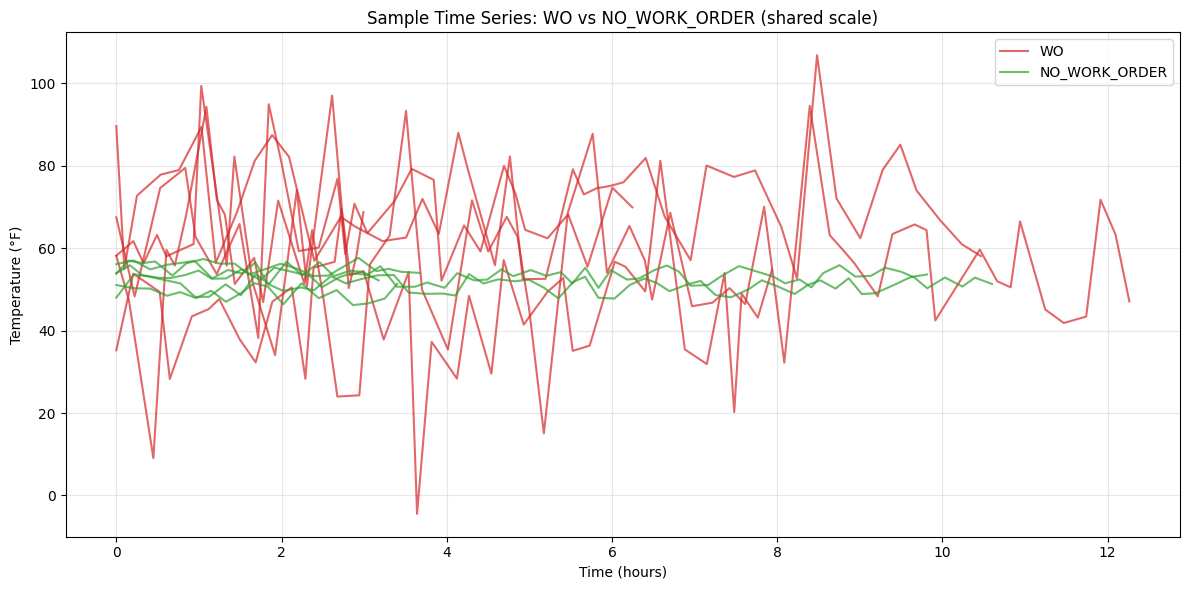

In [21]:
# plotting samples from both classes on the same plot to understand fluctuation

plt.figure(figsize=(12, 6))

wo_samples = df[df['label'] == 'WO'].sample(5)
no_samples = df[df['label'] == 'NO_WORK_ORDER'].sample(5)

# WO
for i, ts in enumerate(wo_samples['timeseries_data']):
    t0 = min(d['timestamp'] for d in ts)
    x = [(d['timestamp'] - t0) / 3600 for d in ts]
    y = [d['temperature'] for d in ts]
    plt.plot(x, y, color='tab:red', alpha=0.7, label='WO' if i == 0 else None)

# NO_WORK_ORDER
for i, ts in enumerate(no_samples['timeseries_data']):
    t0 = min(d['timestamp'] for d in ts)
    x = [(d['timestamp'] - t0) / 3600 for d in ts]
    y = [d['temperature'] for d in ts]
    plt.plot(x, y, color='tab:green', alpha=0.7, label='NO_WORK_ORDER' if i == 0 else None)

plt.title('Sample Time Series: WO vs NO_WORK_ORDER (shared scale)')
plt.xlabel('Time (hours)')
plt.ylabel('Temperature (°F)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(VIZ_DIRECTORY+'01_sample_timeseries.png', dpi=120)
plt.show()

# OBS: Volatility alone separates the classes decently

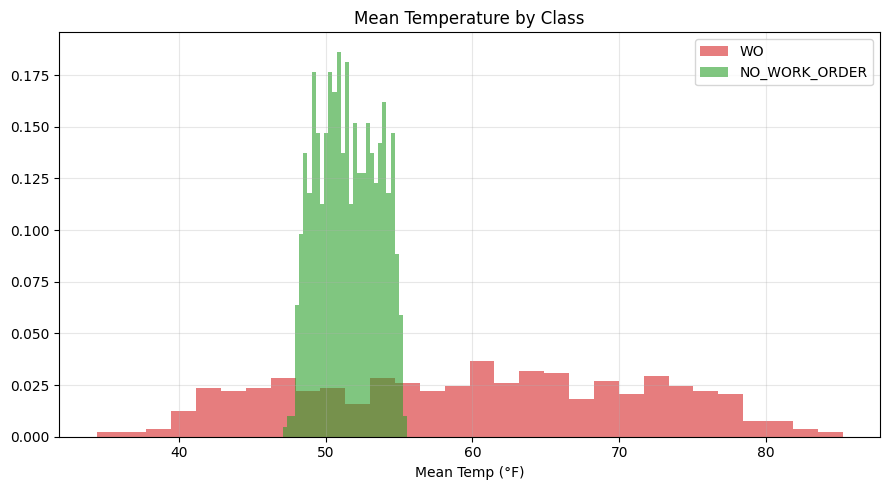

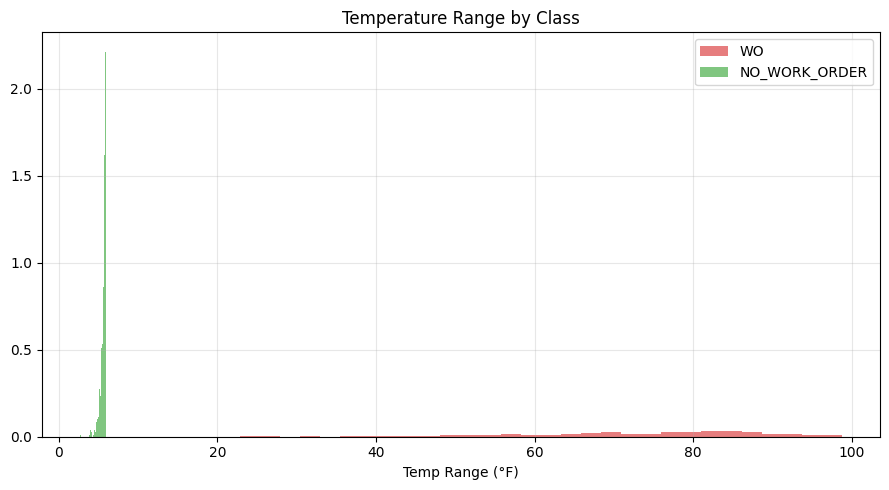

In [22]:
wo_mean = rdf[rdf['label'] == 'WO']['mean_temp']
no_mean = rdf[rdf['label'] == 'NO_WORK_ORDER']['mean_temp']
wo_range = rdf[rdf['label'] == 'WO']['temp_range']
no_range = rdf[rdf['label'] == 'NO_WORK_ORDER']['temp_range']

# Mean Temp
plt.figure(figsize=(9, 5))
plt.hist(wo_mean, bins=30, alpha=0.6, label='WO', color='tab:red', density=True)
plt.hist(no_mean, bins=30, alpha=0.6, label='NO_WORK_ORDER', color='tab:green', density=True)
plt.title('Mean Temperature by Class')
plt.xlabel('Mean Temp (°F)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(VIZ_DIRECTORY+'02a_mean_temp_dist.png', dpi=120)
plt.show()

# Temp Range
plt.figure(figsize=(9, 5))
plt.hist(wo_range, bins=30, alpha=0.6, label='WO', color='tab:red', density=True)
plt.hist(no_range, bins=30, alpha=0.6, label='NO_WORK_ORDER', color='tab:green', density=True)
plt.title('Temperature Range by Class')
plt.xlabel('Temp Range (°F)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(VIZ_DIRECTORY+'02b_temp_range_dist.png', dpi=120)
plt.show()

# OBS: Sharp spike in mean_temp plot
# OBS: temp_range is also a strong feature

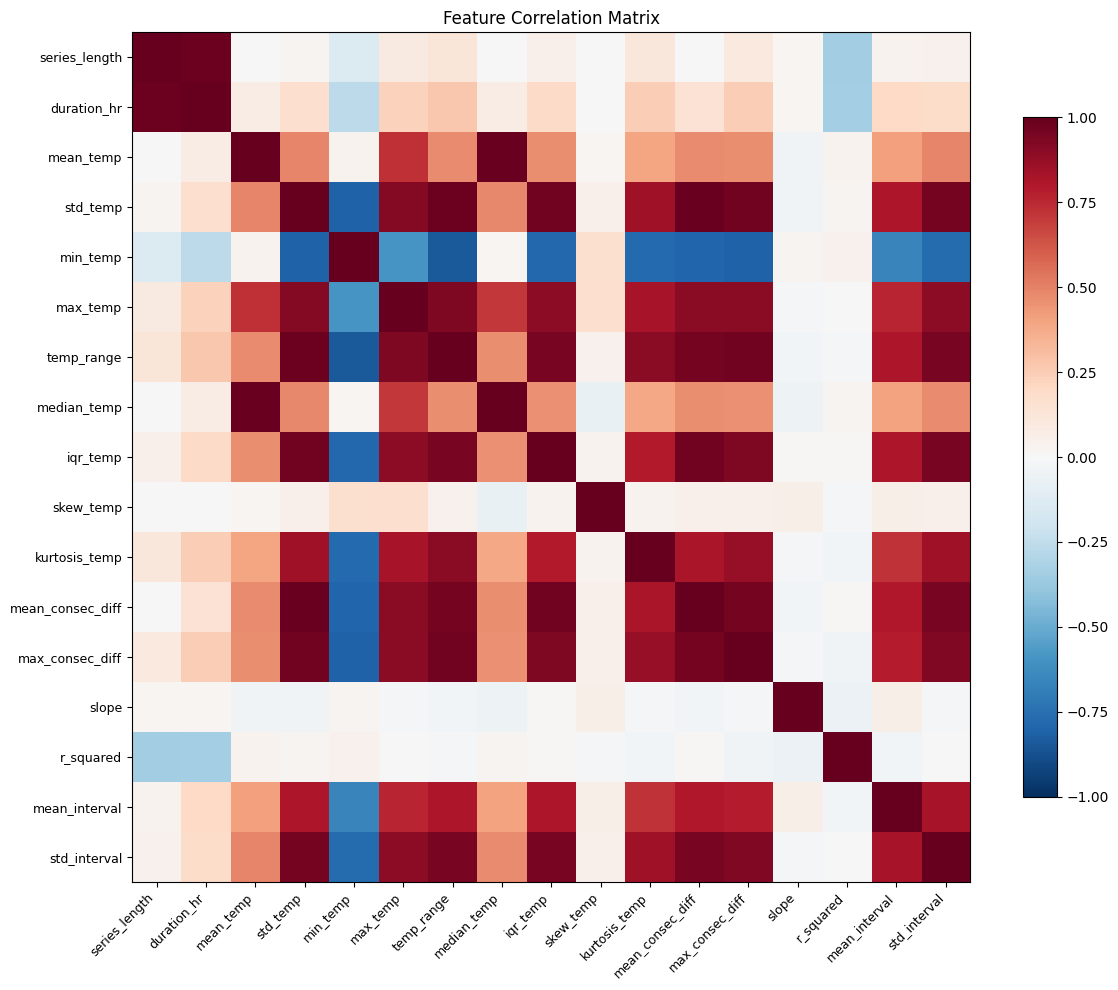

In [23]:
# correlation heatmap of all features
cols = [c for c in rdf.columns if c != 'label']
corr = rdf[cols].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

# Set ticks and labels simultaneously
plt.xticks(range(len(cols)), cols, rotation=45, ha='right', fontsize=9)
plt.yticks(range(len(cols)), cols, fontsize=9)

plt.colorbar(shrink=0.8)
plt.title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig(VIZ_DIRECTORY + '03_correlation.png', dpi=120)
plt.show()


# OBS: variability features (std_temp, temp_range, iqr_temp, mean_consec_diff, max_consec_diff,
#       std_consec_diff) all have 0.9+ correlation with each other. They are redundant.

# OBS: Duration and series_length barely correlate with temperature features.

# OBS: r_squared and slope also have zero correlation with the rest of the features

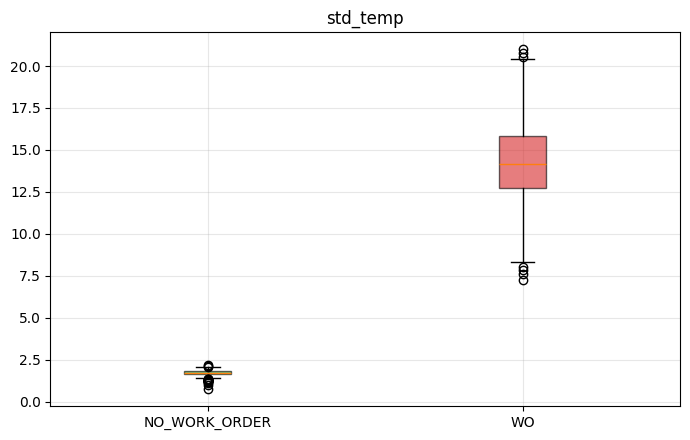

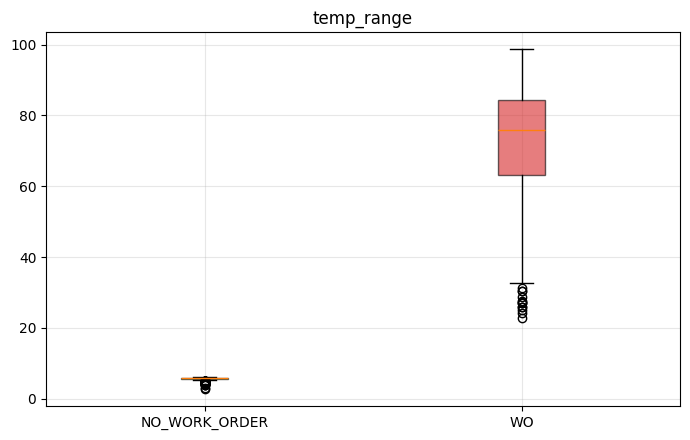

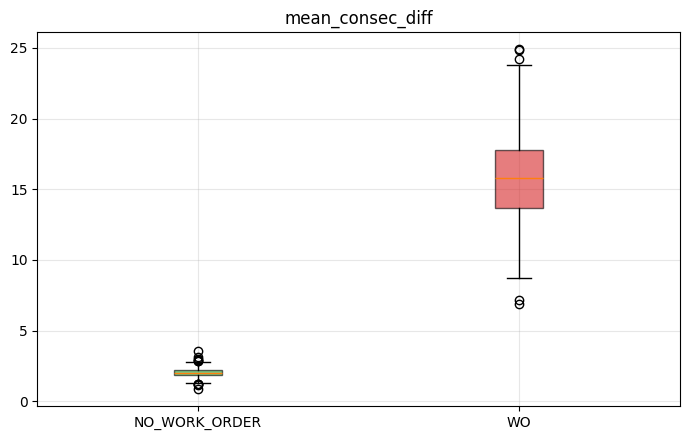

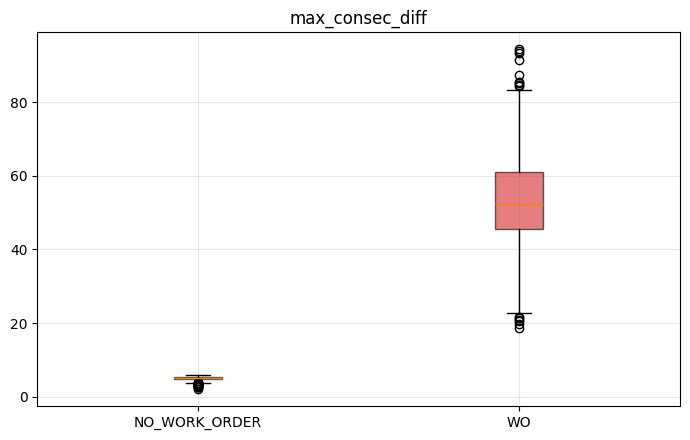

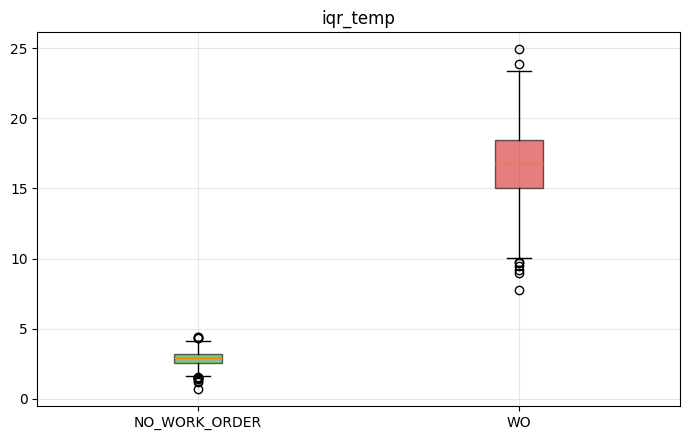

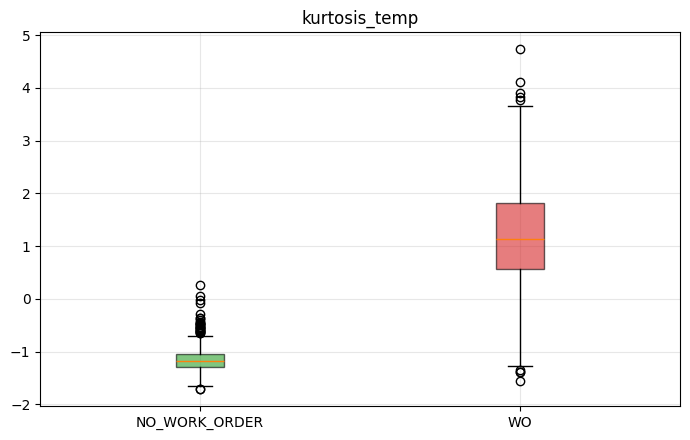

In [24]:
features_to_plot = ['std_temp', 'temp_range', 'mean_consec_diff', 'max_consec_diff', 'iqr_temp', 'kurtosis_temp']

no_df = rdf[rdf['label'] == 'NO_WORK_ORDER']
wo_df = rdf[rdf['label'] == 'WO']

for feat in features_to_plot:
    plt.figure(figsize=(7, 4.5))
    
    bp = plt.boxplot([no_df[feat], wo_df[feat]], tick_labels=['NO_WORK_ORDER', 'WO'], patch_artist=True)
    
    for box, color in zip(bp['boxes'], ['tab:green', 'tab:red']):
        box.set_facecolor(color)
        box.set_alpha(0.6)

    plt.title(feat)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(VIZ_DIRECTORY + '04_box_' + feat + '.png', dpi=120)
    plt.show()

# OBS: the boxes don't overlap at all for std_temp, temp_range, 
#       mean_consec_diff, max_consec_diff, iqr_temp
#       Any one of these features could separate the classes on its own.

# OBS: For kurtosis_temp, boxes overlap a bit. weak signal.

# FEATURE ENGINEERING

In [25]:
from src.features import extract_features, FEATURE_NAMES

X = pd.DataFrame([extract_features(ts) for ts in df['timeseries_data']])
y = (df['label'] == 'WO').astype(int)

print('Feature matrix shape:', X.shape)
print('NaN count:', X.isnull().sum().sum())
print('Target distribution:', y.value_counts().to_dict())
print('\nFinal features:', FEATURE_NAMES)

Feature matrix shape: (1200, 23)
NaN count: 0
Target distribution: {0: 720, 1: 480}

Final features: ['mean_temp', 'std_temp', 'min_temp', 'max_temp', 'median_temp', 'iqr_temp', 'temp_range', 'skew_temp', 'kurtosis_temp', 'duration_sec', 'num_readings', 'mean_interval', 'std_interval', 'slope', 'r_squared', 'mean_consec_diff', 'max_consec_diff', 'std_consec_diff', 'count_above_80', 'count_below_20', 'frac_above_80', 'frac_below_20', 'cv_temp']


# MODELLING

In [26]:
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score
import matplotlib.pyplot as plt

In [ ]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=4404, 
    stratify=y
)
print('Train:', X_train.shape, '\nTest: ', X_test.shape)

Train: (960, 23) 
Test:  (240, 23)


In [28]:
# Since there are barely any outliers, not using a robust scaler.

scaler =StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

joblib.dump(scaler, ARTEFACTS_DIRECTORY+'scaler.joblib')

['../artifacts/scaler.joblib']

In [29]:
logistic = LogisticRegression(
    class_weight="balanced", 
    max_iter=200, 
    random_state=4404
    )
logistic.fit(X_train_s, y_train)

preds_logistic =logistic.predict(X_test_s)
probs_logistic= logistic.predict_proba(X_test_s)[:, 1]

print("--- Logistic Regression ---")
print('\nROC-AUC:', roc_auc_score(y_test, probs_logistic))
print('\nRecall:', recall_score(y_test, preds_logistic))
print('\nConfusion matrix\n', confusion_matrix(y_test, preds_logistic))

joblib.dump(logistic, ARTEFACTS_DIRECTORY+'logistic.joblib')

--- Logistic Regression ---

ROC-AUC: 1.0

Recall: 1.0

Confusion matrix
 [[144   0]
 [  0  96]]


['../artifacts/logistic.joblib']

In [ ]:
random_forest = RandomForestClassifier(
    class_weight='balanced', 
    n_estimators= 100,
    max_depth= 10, 
    random_state=4404
    )
random_forest.fit(X_train,y_train) 

preds_random_forest=random_forest.predict(X_test)
probs_random_forest= random_forest.predict_proba(X_test)[:, 1]

print('--- Random Forest ---')
print("\nROC-AUC:", roc_auc_score(y_test,probs_random_forest))
print('\nRecall:', recall_score(y_test, preds_random_forest))
print('\nConfusion matrix\n', confusion_matrix(y_test, preds_random_forest))

joblib.dump(random_forest, ARTEFACTS_DIRECTORY+"random_forest.joblib")

--- Random Forest ---

ROC-AUC: 1.0

Recall: 1.0

Confusion matrix
 [[144   0]
 [  0  96]]


['../artifacts/random_forest.joblib']

In [31]:
y_train.value_counts()

label
0    576
1    384
Name: count, dtype: int64

In [32]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    scale_pos_weight = scale_pos_weight, 
    random_state = 4404, 
    max_depth = 3, 
    learning_rate = 0.1)

xgb.fit(X_train, y_train)

preds_xgb = xgb.predict(X_test)
probs_xgb = xgb.predict_proba(X_test)[:, 1]

print("--- XGBoost ---")
print('scale_pos_weight: ', scale_pos_weight)
print('\nROC-AUC:', roc_auc_score(y_test,probs_xgb))
print('\nRecall:', recall_score(y_test, preds_xgb))
print('\nConfusion matrix\n', confusion_matrix(y_test,preds_xgb))


joblib.dump(xgb, ARTEFACTS_DIRECTORY+'xgb.joblib')

--- XGBoost ---
scale_pos_weight:  1.5

ROC-AUC: 1.0

Recall: 1.0

Confusion matrix
 [[144   0]
 [  0  96]]


['../artifacts/xgb.joblib']

In [33]:
# Perfect scores by all 3 models did concern me.
# Checking data leak with a stump model per feature.

avg_accuracy = []
for feature in X_test.columns:
    stump = DecisionTreeClassifier(max_depth= 1, random_state=4404)
    stump.fit(X_train[[feature]], y_train)
    stump_acc = stump.score(X_test[[feature]], y_test)
    avg_accuracy.append(stump_acc)
print('Sanity check acc:', np.average(avg_accuracy))

# OBS: Data Leak is not present, it is the features are separable. 

Sanity check acc: 0.880072463768116


Since all 3 mondels have perfect score,

*MOVING AHEAD WITH LOGISTIC REGRESSION DUE TO TIME COMPLEXITY*